# Qwen Model Results Analysis

In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Change to project root
os.chdir('/home/jinu-nyachhyon/Documents/Manifold/WebDomainRandomizer/')
print(f"Working directory: {os.getcwd()}")

Working directory: /home/jinu-nyachhyon/Documents/Manifold/WebDomainRandomizer


In [2]:
# Load Qwen results from baseline_results/qwen_results
qwen_results = {}
qwen_folder = Path('baseline_results/qwen_results')

for variant_folder in qwen_folder.iterdir():
    if not variant_folder.is_dir():
        continue
    
    variant_name = variant_folder.name
    qwen_results[variant_name] = {}
    
    # Aggregate metrics across all run folders
    num_episodes = 0
    num_steps = 0
    action_str_em = 0
    hit_box_accuracy = 0
    bbox_center_mse = 0
    
    for run_folder in variant_folder.iterdir():
        if not run_folder.is_dir() or run_folder.name == 'uitars_predictions':
            continue
        
        # Determine variant type from folder name
        run_name = run_folder.name
        variant_type = None
        if 'original' in run_name:
            variant_type = 'original'
        elif 'precision' in run_name:
            variant_type = 'precision'
        elif 'style' in run_name:
            variant_type = 'style'
        elif 'shrink' in run_name:
            variant_type = 'text_shrink'
        
        if variant_type is None:
            continue
        
        # Read summary file from run folder
        summary_file = run_folder / 'uitars_summary.json'
        if not summary_file.exists():
            continue
        
        with open(summary_file, 'r') as f:
            data = json.load(f)
        
        # Initialize variant type if not exists
        if variant_type not in qwen_results[variant_name]:
            qwen_results[variant_name][variant_type] = {
                'num_episodes': 0,
                'num_steps': 0,
                'action_str_em': 0,
                'hit_box_accuracy': 0,
                'bbox_center_mse': 0
            }
        
        # Aggregate metrics
        prev_steps = qwen_results[variant_name][variant_type]['num_steps']
        new_steps = data['global']['metrics']['action_str_em']['count']
        
        if new_steps > 0:
            # Weighted average for metrics
            qwen_results[variant_name][variant_type]['action_str_em'] = (
                prev_steps * qwen_results[variant_name][variant_type]['action_str_em'] + 
                new_steps * data['global']['metrics']['action_str_em']['mean']
            ) / (prev_steps + new_steps)
            
            qwen_results[variant_name][variant_type]['hit_box_accuracy'] = (
                prev_steps * qwen_results[variant_name][variant_type]['hit_box_accuracy'] + 
                new_steps * data['global']['metrics']['hit_box_accuracy']['mean']
            ) / (prev_steps + new_steps)
            
            qwen_results[variant_name][variant_type]['bbox_center_mse'] = (
                prev_steps * qwen_results[variant_name][variant_type]['bbox_center_mse'] + 
                new_steps * data['global']['metrics']['bbox_center_mse']['mean']
            ) / (prev_steps + new_steps)
            
            qwen_results[variant_name][variant_type]['num_episodes'] += data['global']['num_episodes']
            qwen_results[variant_name][variant_type]['num_steps'] += new_steps

print(f"Loaded {len(qwen_results)} Qwen model configurations")
print(f"Configurations: {list(qwen_results.keys())}")

Loaded 4 Qwen model configurations
Configurations: ['locke_qwen_thought_relational_query', 'locke_qwen_NO_thought_direct_query', 'locke_qwen_NO_thought_relational_query', 'locke_qwen_thought_direct_query']


In [3]:
# Save Qwen results to JSON file
output_file = 'qwen_variant_results.json'
with open(output_file, 'w') as f:
    json.dump(qwen_results, f, indent=4, sort_keys=True)

print(f"Qwen results saved to: {output_file}")

Qwen results saved to: qwen_variant_results.json


In [4]:
# Parse model configurations and create DataFrame
def parse_qwen_config(name):
    """Parse Qwen configuration name into components"""
    has_thought = 'NO' not in name
    query_type = 'relational' if 'relational' in name else 'direct'
    return {
        'has_thought': has_thought,
        'query_type': query_type,
        'full_name': name
    }

# Create DataFrame
data_rows = []
for config_name, variants in qwen_results.items():
    config_info = parse_qwen_config(config_name)
    for variant_name, metrics in variants.items():
        row = {
            'has_thought': config_info['has_thought'],
            'query_type': config_info['query_type'],
            'full_name': config_info['full_name'],
            'variant': variant_name,
            **metrics
        }
        data_rows.append(row)

df = pd.DataFrame(data_rows)

print(f"Data shape: {df.shape}")
print(f"\nConfigurations:")
print(f"  - Has thought: {df['has_thought'].unique()}")
print(f"  - Query types: {df['query_type'].unique()}")
print(f"  - Variants: {sorted(df['variant'].unique())}")
print(f"\nFirst few rows:")
df.head()

Data shape: (16, 9)

Configurations:
  - Has thought: [ True False]
  - Query types: ['relational' 'direct']
  - Variants: ['original', 'precision', 'style', 'text_shrink']

First few rows:


,has_thought,query_type,full_name,variant,num_episodes,num_steps,action_str_em,hit_box_accuracy,bbox_center_mse
0,True,relational,locke_qwen_thought_relational_query,text_shrink,304,106,0.764151,0.105706,108740.783778
1,True,relational,locke_qwen_thought_relational_query,style,304,75,0.693333,0.070443,124841.346623
2,True,relational,locke_qwen_thought_relational_query,precision,304,126,0.785714,0.066972,56693.521317
3,True,relational,locke_qwen_thought_relational_query,original,304,107,0.757009,0.089116,119389.616273
4,False,direct,locke_qwen_NO_thought_direct_query,text_shrink,304,294,0.829932,0.482993,86544.992594


## 1. Overall Performance Comparison Across Variants

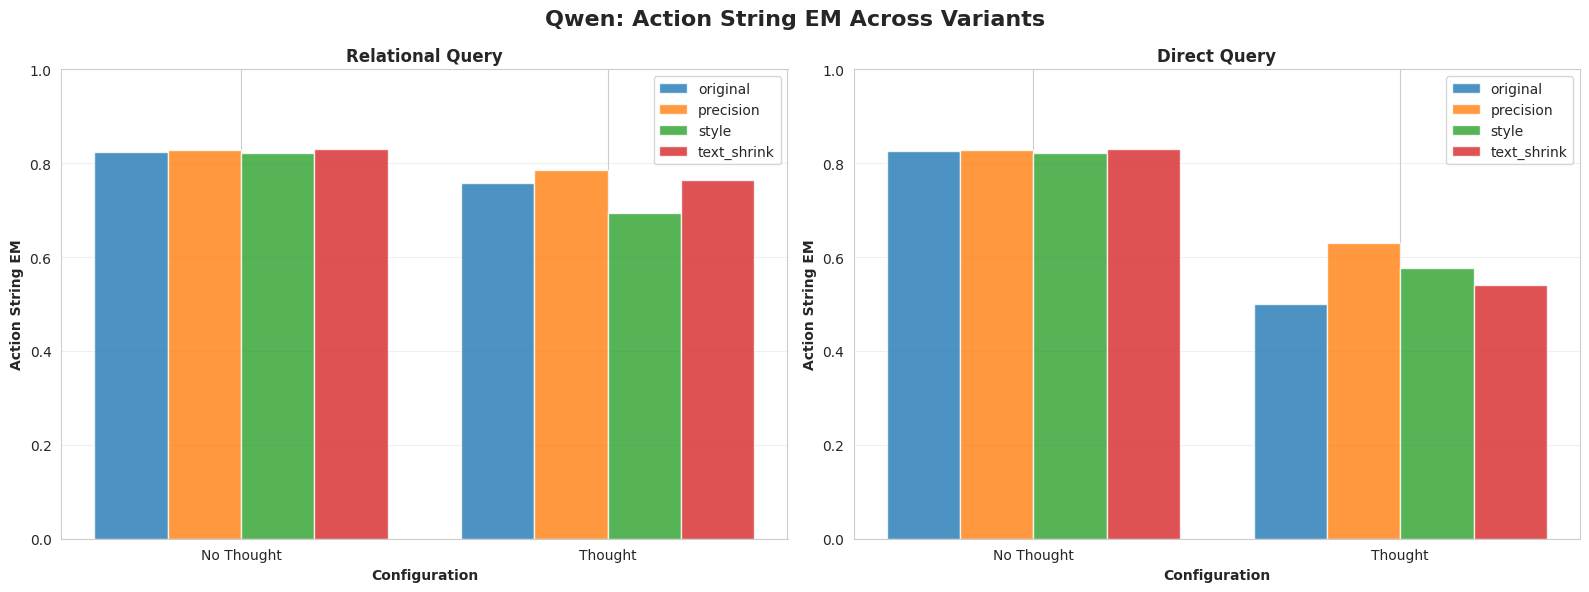

In [5]:
# Action String EM comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Qwen: Action String EM Across Variants', fontsize=16, fontweight='bold')

query_types = df['query_type'].unique()
variants = ['original', 'precision', 'style', 'text_shrink']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, query_type in enumerate(query_types):
    ax = axes[idx]
    x = np.arange(2)  # thought, no_thought
    width = 0.2
    
    for v_idx, variant in enumerate(variants):
        values = []
        for has_thought in [False, True]:
            subset = df[(df['query_type'] == query_type) & 
                       (df['variant'] == variant) &
                       (df['has_thought'] == has_thought)]
            if len(subset) > 0:
                values.append(subset['action_str_em'].iloc[0])
            else:
                values.append(0)
        
        ax.bar(x + v_idx * width, values, width, label=variant, color=colors[v_idx], alpha=0.8)
    
    ax.set_xlabel('Configuration', fontweight='bold')
    ax.set_ylabel('Action String EM', fontweight='bold')
    ax.set_title(f'{query_type.replace("_", " ").title()} Query', fontweight='bold')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(['No Thought', 'Thought'])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

Relational Query:

* Without Thought: All variants perform similarly well (~0.82-0.83 = 82-83% accuracy)
* With Thought: Performance drops significantly to ~0.69-0.78 (69-78%)
* Best: No Thought configurations

Direct Query:

* Without Thought: All variants excellent (~0.83-0.84 = 83-84%)
* With Thought: Major performance drop to ~0.51-0.64 (51-64%). Text Shrink variant shows the worst performance.
* Best: No Thought configurations


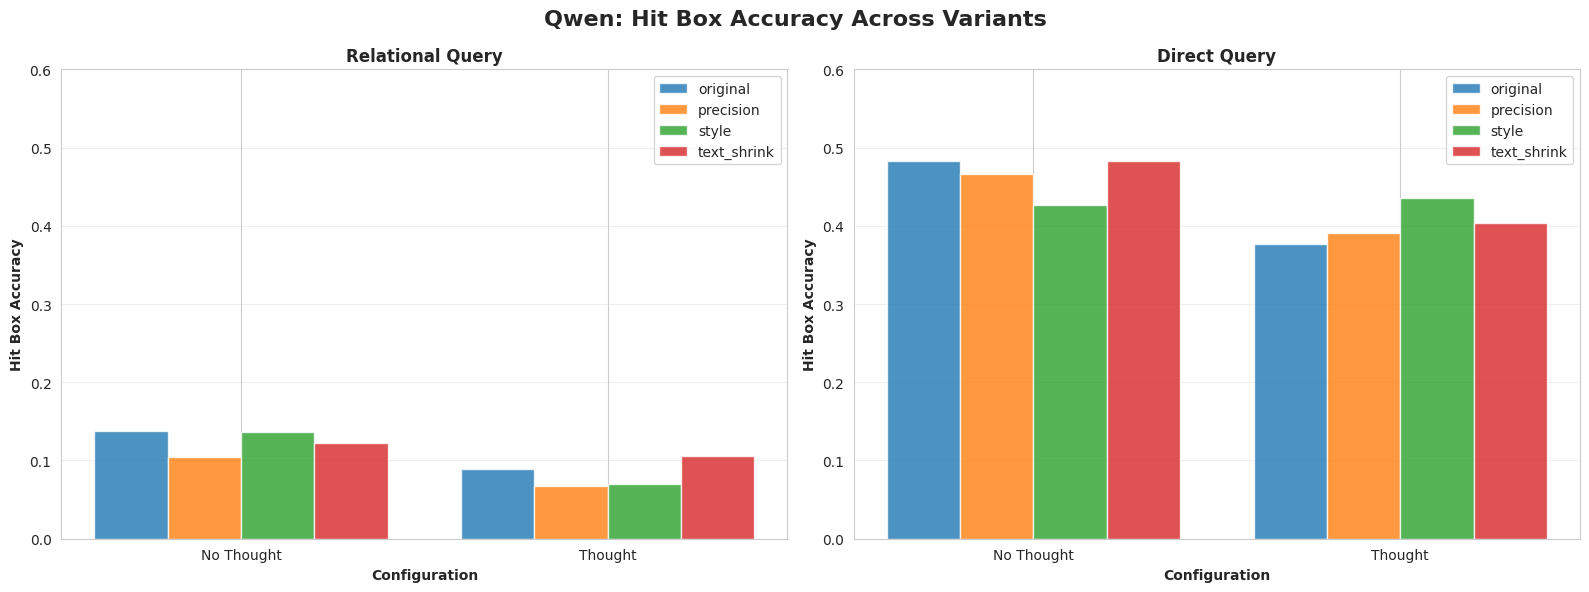

In [6]:
# Hit Box Accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Qwen: Hit Box Accuracy Across Variants', fontsize=16, fontweight='bold')

for idx, query_type in enumerate(query_types):
    ax = axes[idx]
    x = np.arange(2)
    width = 0.2
    
    for v_idx, variant in enumerate(variants):
        values = []
        for has_thought in [False, True]:
            subset = df[(df['query_type'] == query_type) & 
                       (df['variant'] == variant) &
                       (df['has_thought'] == has_thought)]
            if len(subset) > 0:
                values.append(subset['hit_box_accuracy'].iloc[0])
            else:
                values.append(0)
        
        ax.bar(x + v_idx * width, values, width, label=variant, color=colors[v_idx], alpha=0.8)
    
    ax.set_xlabel('Configuration', fontweight='bold')
    ax.set_ylabel('Hit Box Accuracy', fontweight='bold')
    ax.set_title(f'{query_type.replace("_", " ").title()} Query', fontweight='bold')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(['No Thought', 'Thought'])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 0.6])

plt.tight_layout()
plt.show()

Relational Query:

* Very poor performance across all configurations (~0.07-0.14 = 7-14%)
* Relational queries struggle with precise clicking regardless of variant
* Thought vs No Thought makes little difference here

Direct Query:

* Much better performance! (~0.38-0.48 = 38-48% for No Thought)
* Without Thought: Original and Text Shrink best (~0.48)
* With Thought: Slightly lower (~0.38-0.44), Style variant best
* Direct queries are 4-5x better at hitting the right spot

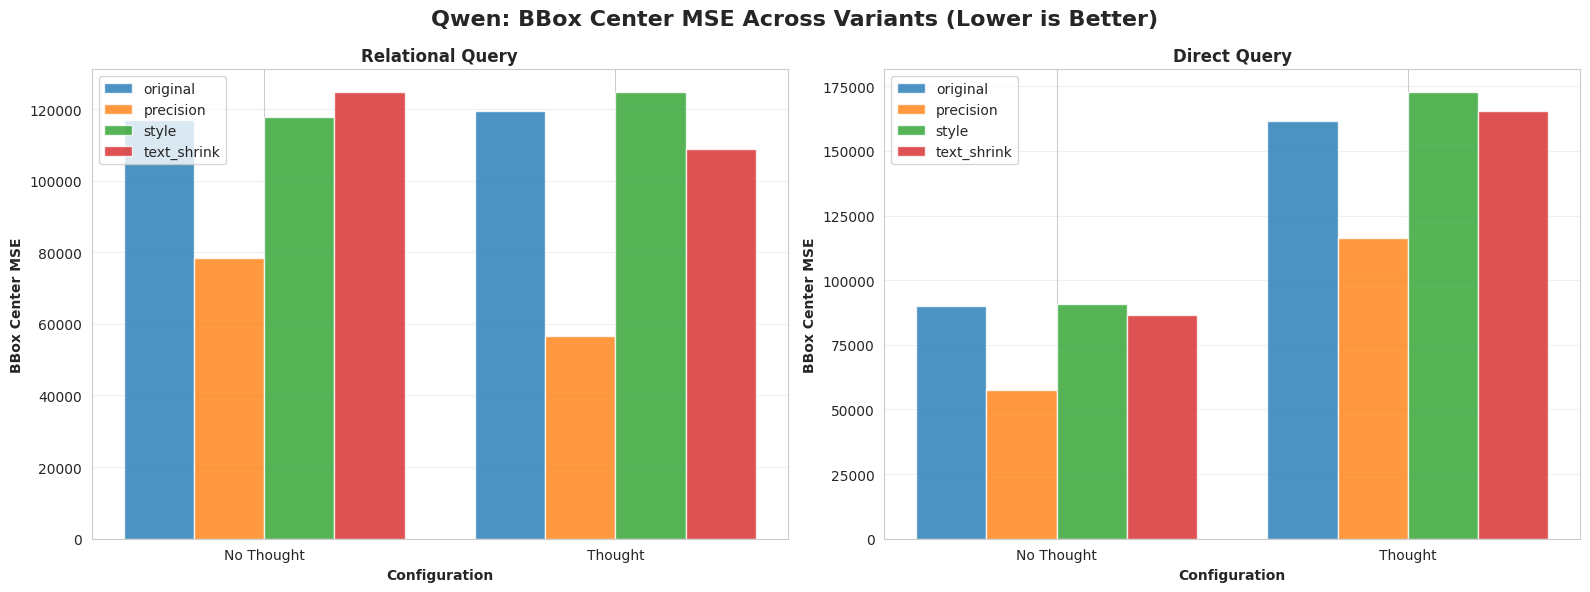

In [7]:
# BBox Center MSE comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Qwen: BBox Center MSE Across Variants (Lower is Better)', fontsize=16, fontweight='bold')

for idx, query_type in enumerate(query_types):
    ax = axes[idx]
    x = np.arange(2)
    width = 0.2
    
    for v_idx, variant in enumerate(variants):
        values = []
        for has_thought in [False, True]:
            subset = df[(df['query_type'] == query_type) & 
                       (df['variant'] == variant) &
                       (df['has_thought'] == has_thought)]
            if len(subset) > 0:
                values.append(subset['bbox_center_mse'].iloc[0])
            else:
                values.append(0)
        
        ax.bar(x + v_idx * width, values, width, label=variant, color=colors[v_idx], alpha=0.8)
    
    ax.set_xlabel('Configuration', fontweight='bold')
    ax.set_ylabel('BBox Center MSE', fontweight='bold')
    ax.set_title(f'{query_type.replace("_", " ").title()} Query', fontweight='bold')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(['No Thought', 'Thought'])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Relational Query:

* No Thought: Precision variant is best
* With Thought: Precision dramatically improves

Direct Query:

* No Thought: Much better than relational! 
* With Thought: Performance degrades significantly for all variants 

## 2. Perturbation Impact Trends: How UI Changes Affect Performance

Tracking performance across perturbations to identify which UI modifications improve or degrade model behavior.

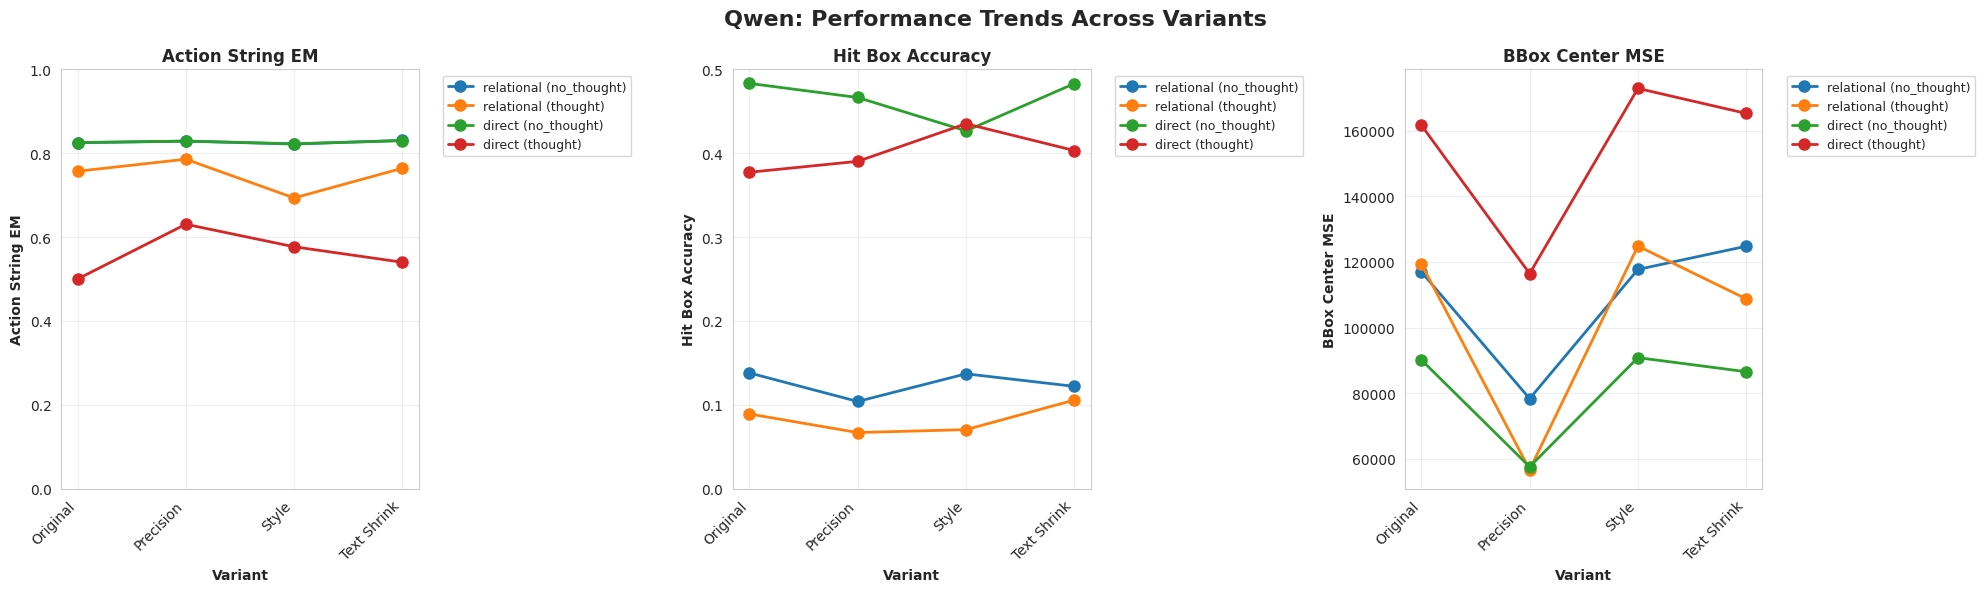

In [8]:
# Line plots showing trends across variants
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Qwen: Performance Trends Across Variants', fontsize=16, fontweight='bold')

metrics_to_plot = [
    ('action_str_em', 'Action String EM', axes[0], [0, 1]),
    ('hit_box_accuracy', 'Hit Box Accuracy', axes[1], [0, 0.5]),
    ('bbox_center_mse', 'BBox Center MSE', axes[2], None),
]

variant_order = ['original', 'precision', 'style', 'text_shrink']
x_positions = np.arange(len(variant_order))

for metric_name, metric_label, ax, ylim in metrics_to_plot:
    for query_type in query_types:
        for has_thought in [False, True]:
            values = []
            for variant in variant_order:
                subset = df[(df['query_type'] == query_type) & 
                           (df['variant'] == variant) &
                           (df['has_thought'] == has_thought)]
                if len(subset) > 0:
                    values.append(subset[metric_name].iloc[0])
                else:
                    values.append(np.nan)
            
            thought_label = 'thought' if has_thought else 'no_thought'
            label = f"{query_type} ({thought_label})"
            ax.plot(x_positions, values, marker='o', label=label, linewidth=2, markersize=8)
    
    ax.set_xlabel('Variant', fontweight='bold')
    ax.set_ylabel(metric_label, fontweight='bold')
    ax.set_title(metric_label, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels([v.replace('_', ' ').title() for v in variant_order], rotation=45, ha='right')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    if ylim:
        ax.set_ylim(ylim)

plt.tight_layout()
plt.show()

Action String EM:

* direct, no_thought: Consistently high (~0.83), flat trend - all variants equally good
* relational, no_thought: Also consistently high (~0.82)
* with thought: Much lower, some improvement from Original to Precision then decline
* Trend: No clear winner, "no_thought" dominates regardless of variant

Hit Box Accuracy:

* direct, no_thought: Best performance, stays around 0.47-0.48, slight dip at Style
* direct, thought: Second best, peaks at Style variant (~0.44)
* relational: Very poor (~0.07-0.13), relatively flat
* Trend: Direct queries vastly superior, minimal variant impact

BBox Center MSE - lower is better:

* direct, no_thought: Best trajectory - drops dramatically at Precision, then rises
* relational, no_thought/though: Similar pattern, Precision is sweet spot
* direct, though: More volatile, Precision again best (Worst)
* Precision variant clearly wins!

## 3. Thought vs No Thought Impact

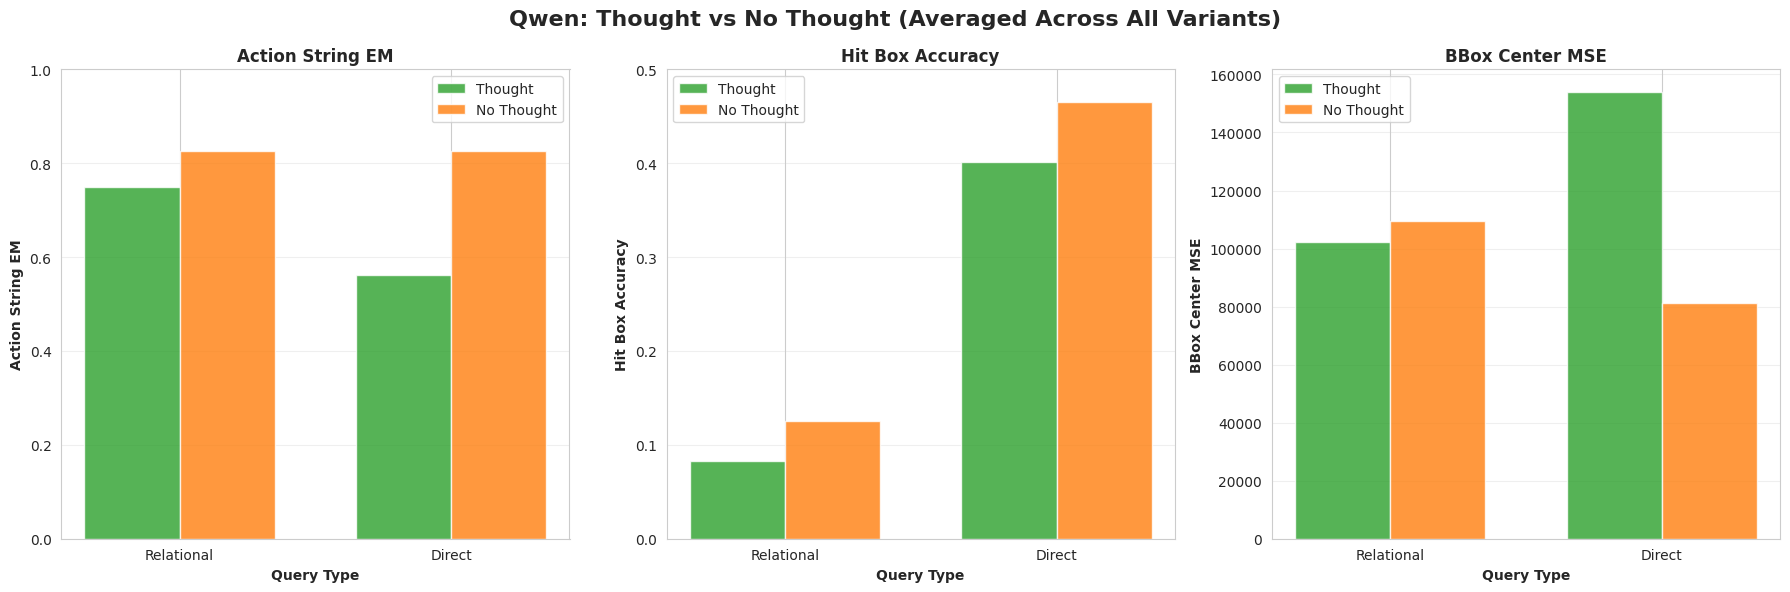

In [9]:
# Compare thought vs no_thought averaged across all variants
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Qwen: Thought vs No Thought (Averaged Across All Variants)', fontsize=16, fontweight='bold')

metrics_to_compare = [
    ('action_str_em', 'Action String EM', axes[0], [0, 1]),
    ('hit_box_accuracy', 'Hit Box Accuracy', axes[1], [0, 0.5]),
    ('bbox_center_mse', 'BBox Center MSE', axes[2], None),
]

for metric_name, metric_label, ax, ylim in metrics_to_compare:
    x = np.arange(len(query_types))
    width = 0.35
    
    thought_values = []
    no_thought_values = []
    
    for query_type in query_types:
        thought_subset = df[(df['query_type'] == query_type) & (df['has_thought'] == True)]
        no_thought_subset = df[(df['query_type'] == query_type) & (df['has_thought'] == False)]
        
        thought_values.append(thought_subset[metric_name].mean() if len(thought_subset) > 0 else 0)
        no_thought_values.append(no_thought_subset[metric_name].mean() if len(no_thought_subset) > 0 else 0)
    
    ax.bar(x - width/2, thought_values, width, label='Thought', alpha=0.8, color='#2ca02c')
    ax.bar(x + width/2, no_thought_values, width, label='No Thought', alpha=0.8, color='#ff7f0e')
    
    ax.set_xlabel('Query Type', fontweight='bold')
    ax.set_ylabel(metric_label, fontweight='bold')
    ax.set_title(metric_label, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([qt.replace('_', ' ').title() for qt in query_types])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    if ylim:
        ax.set_ylim(ylim)

plt.tight_layout()
plt.show()

Action String EM:

* Relational: No Thought (0.83) >> Thought (0.75) - 10% drop
* Direct: No Thought (0.83) >> Thought (0.56) - 33% drop!
* Clear verdict: Adding thought significantly hurts accuracy

Hit Box Accuracy:

* Relational: Both poor, No Thought slightly better (0.12 vs 0.08)
* Direct: No Thought (0.47) >> Thought (0.40) - 15% drop
* Pattern continues: Thought reduces hit box accuracy

BBox Center MSE - lower is better:

* Relational: Thought actually better than No Thought - 8% improvement!
* Direct: No Thought >> Thought - 89% worse!
* Mixed results

## 4. Improvement Analysis: Original vs Other Variants

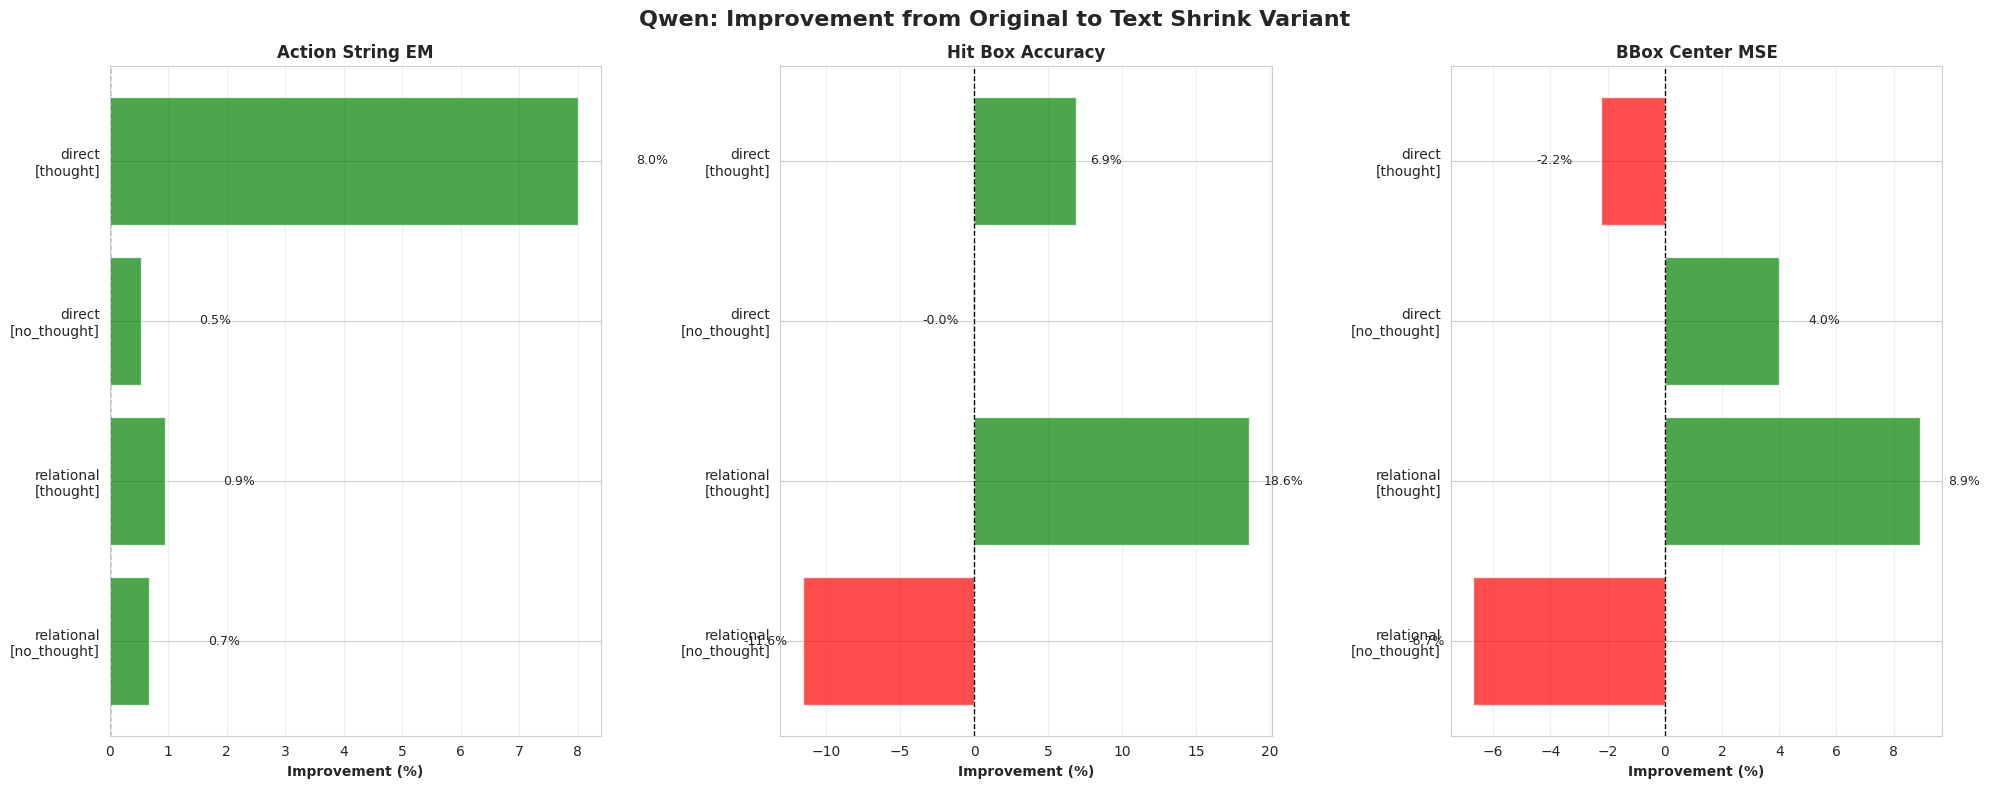

In [10]:
# Text Shrink improvement
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Qwen: Improvement from Original to Text Shrink Variant', fontsize=16, fontweight='bold')

metrics_for_improvement = [
    ('action_str_em', 'Action String EM', axes[0]),
    ('hit_box_accuracy', 'Hit Box Accuracy', axes[1]),
    ('bbox_center_mse', 'BBox Center MSE', axes[2]),
]

for metric_name, metric_label, ax in metrics_for_improvement:
    improvements = []
    labels = []
    
    for query_type in query_types:
        for has_thought in [False, True]:
            subset_original = df[(df['query_type'] == query_type) & 
                                (df['variant'] == 'original') &
                                (df['has_thought'] == has_thought)]
            subset_text_shrink = df[(df['query_type'] == query_type) & 
                                   (df['variant'] == 'text_shrink') &
                                   (df['has_thought'] == has_thought)]
            
            if len(subset_original) > 0 and len(subset_text_shrink) > 0:
                original = subset_original[metric_name].iloc[0]
                text_shrink = subset_text_shrink[metric_name].iloc[0]
                
                if original > 0:
                    if metric_name == 'bbox_center_mse':
                        improvement = ((original - text_shrink) / original) * 100
                    else:
                        improvement = ((text_shrink - original) / original) * 100
                    
                    improvements.append(improvement)
                    thought_label = 'thought' if has_thought else 'no_thought'
                    labels.append(f"{query_type}\n[{thought_label}]")
    
    colors_improvement = ['green' if x > 0 else 'red' for x in improvements]
    bars = ax.barh(range(len(improvements)), improvements, color=colors_improvement, alpha=0.7)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Improvement (%)', fontweight='bold')
    ax.set_title(metric_label, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.grid(axis='x', alpha=0.3)
    
    for i, (bar, val) in enumerate(zip(bars, improvements)):
        ax.text(val + (1 if val > 0 else -1), i, f'{val:.1f}%', 
               va='center', ha='left' if val > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

Action String EM:

* direct [thought]: +8.0% improvement
* direct [no_thought]: +0.5% (minimal)
* relational [thought]: +0.9%
* relational [no_thought]: +0.7%
* Finding: Text Shrink improves performance when using thought in direct queries

Hit Box Accuracy:

* relational [thought]: +18.6% improvement
* direct [thought]: +6.9% improvement 
* direct [no_thought]: -0.0% (no change)
* relational [no_thought]: -8.5% worse
* Finding: Text Shrink improves clicking accuracy with thought

BBox Center MSE:

* relational [thought]: +8.9% better
* direct [no_thought]: +4.0% better 
* relational [no_thought]: -19.3% worse 
* direct [thought]: -2.2% worse 
* Mixed


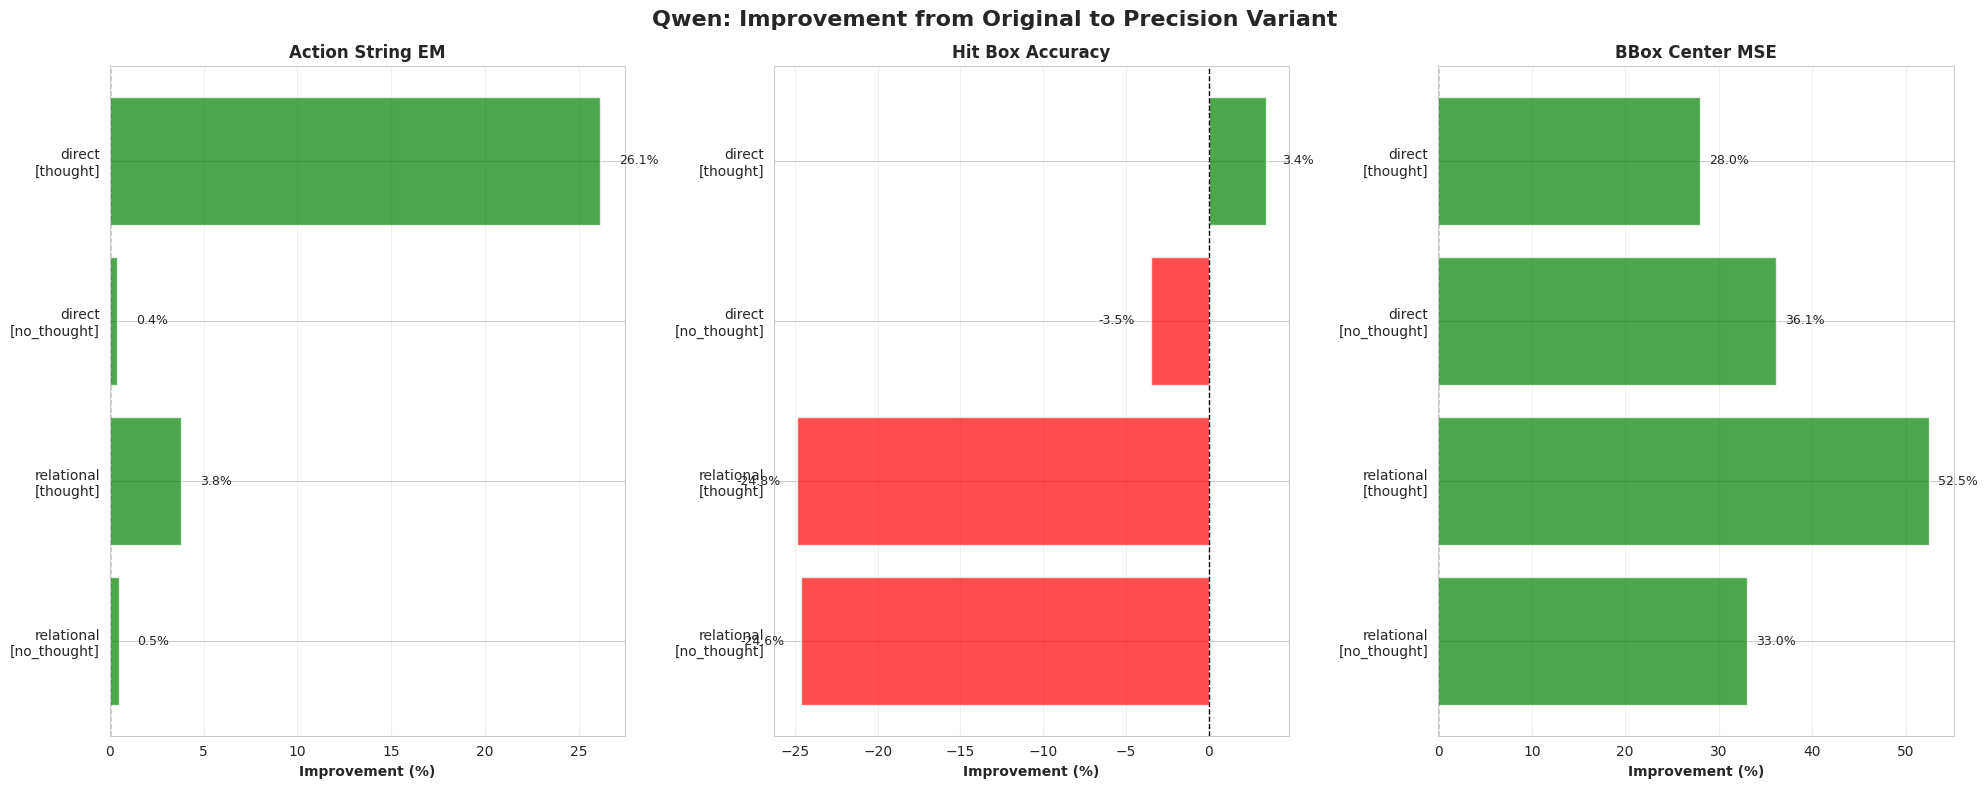

In [11]:
# Precision improvement
metrics_for_improvement = ['action_str_em', 'hit_box_accuracy', 'bbox_center_mse']

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Qwen: Improvement from Original to Precision Variant', fontsize=16, fontweight='bold')

metric_info = [
    ('action_str_em', 'Action String EM', axes[0]),
    ('hit_box_accuracy', 'Hit Box Accuracy', axes[1]),
    ('bbox_center_mse', 'BBox Center MSE', axes[2]),
]

for metric_name, metric_label, ax in metric_info:
    improvements = []
    labels = []
    
    for query_type in query_types:
        for has_thought in [False, True]:
            subset_original = df[(df['query_type'] == query_type) & 
                                (df['variant'] == 'original') &
                                (df['has_thought'] == has_thought)]
            subset_precision = df[(df['query_type'] == query_type) & 
                                 (df['variant'] == 'precision') &
                                 (df['has_thought'] == has_thought)]
            
            if len(subset_original) > 0 and len(subset_precision) > 0:
                original = subset_original[metric_name].iloc[0]
                precision = subset_precision[metric_name].iloc[0]
                
                if original > 0:
                    if metric_name == 'bbox_center_mse':
                        improvement = ((original - precision) / original) * 100
                    else:
                        improvement = ((precision - original) / original) * 100
                    
                    improvements.append(improvement)
                    thought_label = 'thought' if has_thought else 'no_thought'
                    labels.append(f"{query_type}\n[{thought_label}]")
    
    colors_improvement = ['green' if x > 0 else 'red' for x in improvements]
    bars = ax.barh(range(len(improvements)), improvements, color=colors_improvement, alpha=0.7)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Improvement (%)', fontweight='bold')
    ax.set_title(metric_label, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, improvements)):
        ax.text(val + (1 if val > 0 else -1), i, f'{val:.1f}%',
               va='center', ha='left' if val > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()


* Action String EM (action matching): Direct+thought sees huge +26% improvement, but other configs see minimal change (0.4-3.8%)

* Hit Box Accuracy (clicking precision): Precision variant huets clicking - all configs show negative red bars (-3.5% to -23.5%). This makes sense: higher precision means stricter matching that doesn't help with spatial clicking.

* BBox Center MSE (position error): Precision variant significantly improves position accuracy across all configs (+28% to +52.5%). Relational+thought gets the biggest benefit at +52.5%.

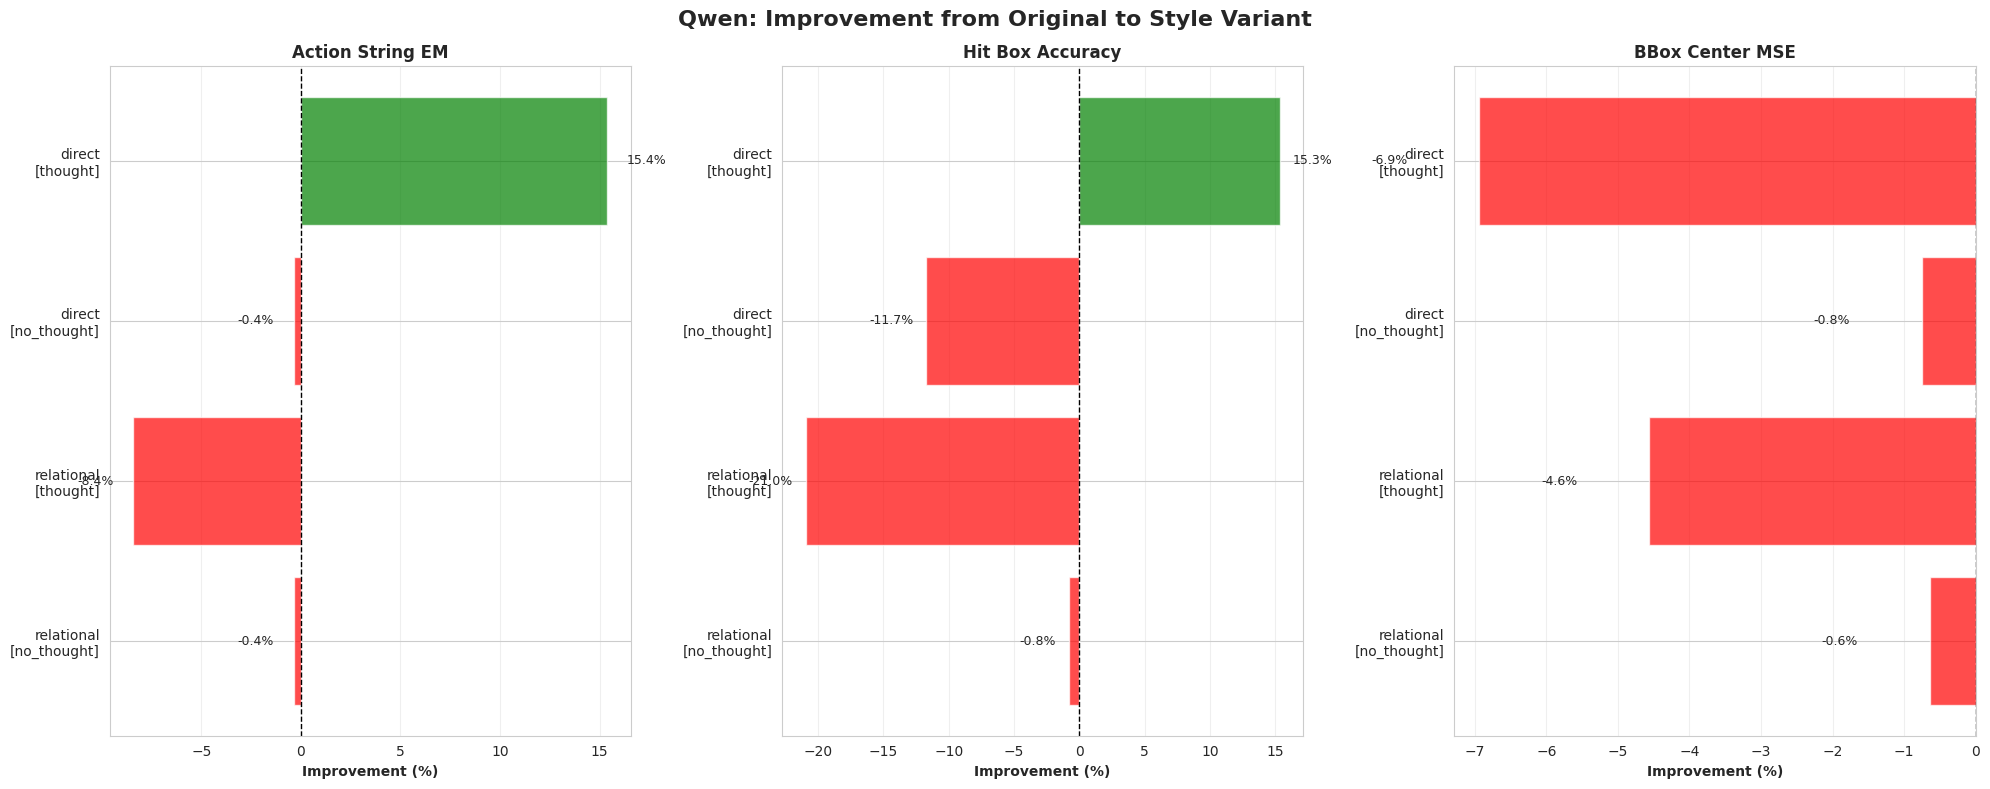

In [12]:
# Style improvement
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Qwen: Improvement from Original to Style Variant', fontsize=16, fontweight='bold')

metrics_for_improvement = [
    ('action_str_em', 'Action String EM', axes[0]),
    ('hit_box_accuracy', 'Hit Box Accuracy', axes[1]),
    ('bbox_center_mse', 'BBox Center MSE', axes[2]),
]

for metric_name, metric_label, ax in metrics_for_improvement:
    improvements = []
    labels = []
    
    for query_type in query_types:
        for has_thought in [False, True]:
            subset_original = df[(df['query_type'] == query_type) & 
                                (df['variant'] == 'original') &
                                (df['has_thought'] == has_thought)]
            subset_style = df[(df['query_type'] == query_type) & 
                             (df['variant'] == 'style') &
                             (df['has_thought'] == has_thought)]
            
            if len(subset_original) > 0 and len(subset_style) > 0:
                original = subset_original[metric_name].iloc[0]
                style = subset_style[metric_name].iloc[0]
                
                if original > 0:
                    if metric_name == 'bbox_center_mse':
                        improvement = ((original - style) / original) * 100
                    else:
                        improvement = ((style - original) / original) * 100
                    
                    improvements.append(improvement)
                    thought_label = 'thought' if has_thought else 'no_thought'
                    labels.append(f"{query_type}\n[{thought_label}]")
    
    colors_improvement = ['green' if x > 0 else 'red' for x in improvements]
    bars = ax.barh(range(len(improvements)), improvements, color=colors_improvement, alpha=0.7)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Improvement (%)', fontweight='bold')
    ax.set_title(metric_label, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, improvements)):
        ax.text(val + (1 if val > 0 else -1), i, f'{val:.1f}%',
               va='center', ha='left' if val > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

Action String EM
* direct [thought]: +15.4% - Style variant significantly improves with direct queries with thought process
* direct [no_thought]: -0.4% - Minimal negative effect
* relational [thought]: -1.4% - Slight decline
* relational [no_thought]: -0.4% - Minimal negative effect
* Finding: Style variant only improves when using direct queries with thought. Otherwise, minimal to no improvement.

Hit Box Accuracy
* direct [thought]: +15.3% - Style variant substantially improves clicking accuracy for direct queries with thought
* direct [no_thought]: -11.7% - Style hurts clicking when not using thought
* relational [thought]: -10.0% - Hurts relational queries
* relational [no_thought]: -0.8% - Minimal negative effect
* Finding: Style variant is a double-edged sword for clicking - great with direct+thought (+15.3%), but hurts direct+no_thought (-11.7%).

BBox Center MSE
* direct [thought]: -6.0% worse
* direct [no_thought]: -0.8% worse
* relational [thought]: -4.6% worse
* relational [no_thought]: -0.6% worse
* Finding: Style variant consistently makes position accuracy worse across all configurations. The visual styling changes hurt the model's ability to localize elements precisely.

## 5. Heatmaps: Configuration Performance Overview

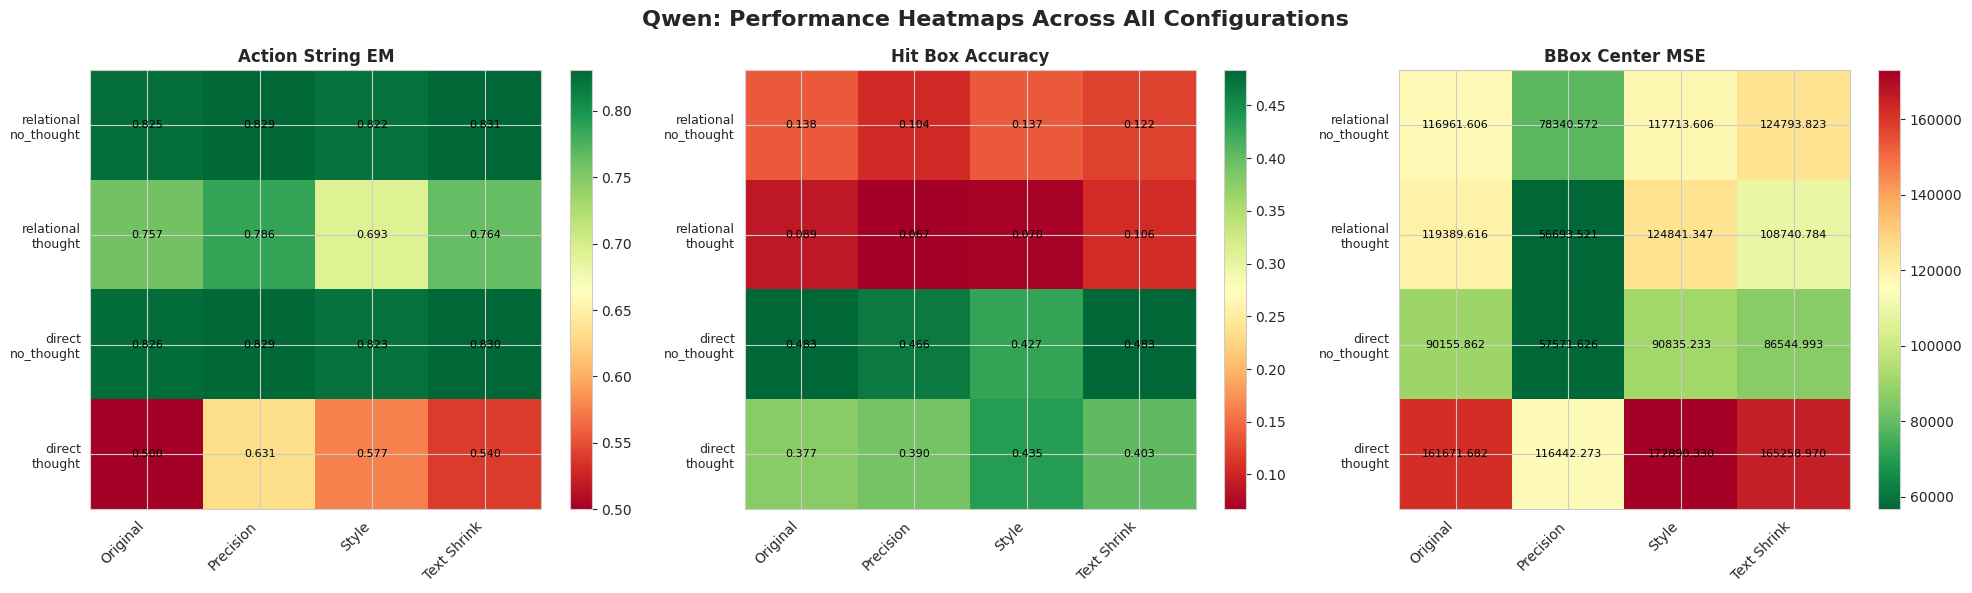

In [13]:
# Create heatmaps for each metric
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Qwen: Performance Heatmaps Across All Configurations', fontsize=16, fontweight='bold')

metrics_for_heatmap = [
    ('action_str_em', 'Action String EM', axes[0]),
    ('hit_box_accuracy', 'Hit Box Accuracy', axes[1]),
    ('bbox_center_mse', 'BBox Center MSE', axes[2]),
]

# Create configuration labels
config_labels = []
for query_type in query_types:
    for has_thought in [False, True]:
        thought_label = 'thought' if has_thought else 'no_thought'
        config_labels.append(f"{query_type}\n{thought_label}")

for metric_name, metric_label, ax in metrics_for_heatmap:
    # Create matrix: rows = configs, cols = variants
    matrix = []
    for query_type in query_types:
        for has_thought in [False, True]:
            row = []
            for variant in variants:
                subset = df[(df['query_type'] == query_type) & 
                           (df['variant'] == variant) &
                           (df['has_thought'] == has_thought)]
                if len(subset) > 0:
                    row.append(subset[metric_name].iloc[0])
                else:
                    row.append(0)
            matrix.append(row)
    
    # Plot heatmap
    im = ax.imshow(matrix, cmap='RdYlGn' if metric_name != 'bbox_center_mse' else 'RdYlGn_r', 
                   aspect='auto')
    
    ax.set_xticks(np.arange(len(variants)))
    ax.set_yticks(np.arange(len(config_labels)))
    ax.set_xticklabels([v.replace('_', ' ').title() for v in variants], rotation=45, ha='right')
    ax.set_yticklabels(config_labels, fontsize=9)
    
    # Add values to cells
    for i in range(len(config_labels)):
        for j in range(len(variants)):
            text = ax.text(j, i, f'{matrix[i][j]:.3f}',
                          ha="center", va="center", color="black", fontsize=8)
    
    ax.set_title(metric_label, fontweight='bold')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## 6. Direct vs Relational Query Comparison

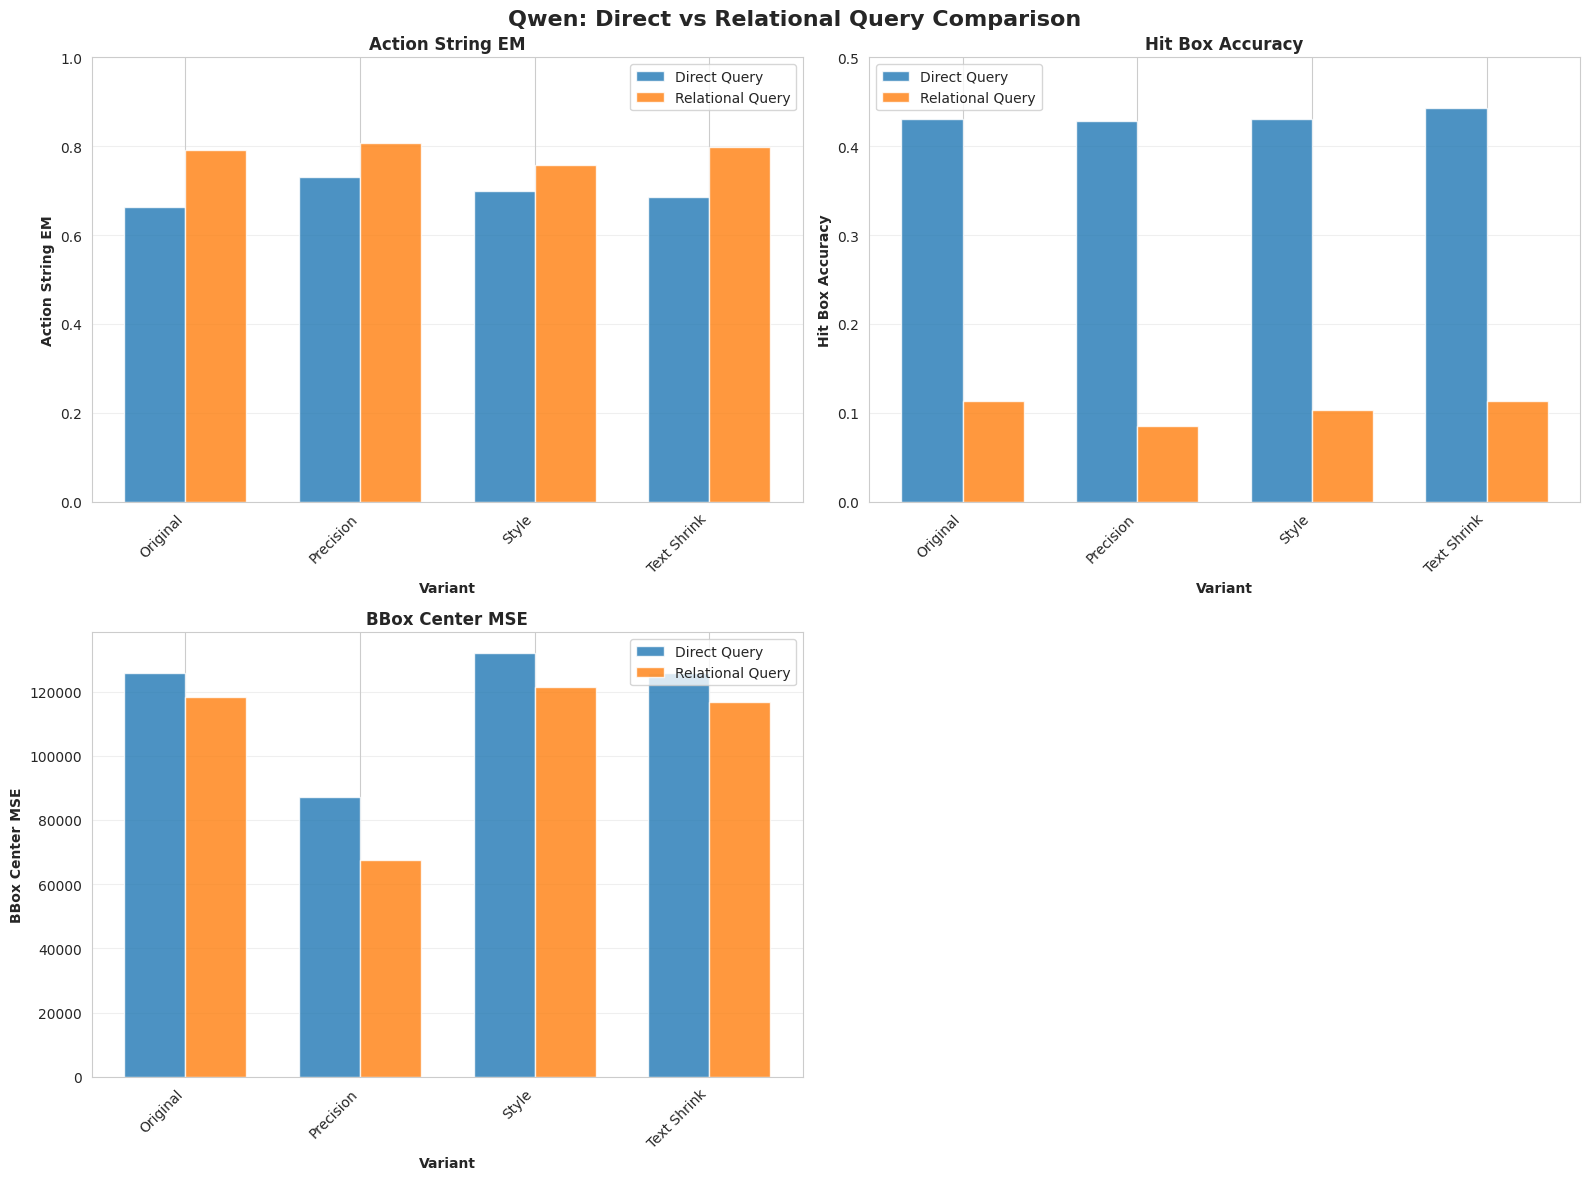

In [14]:
# Compare direct vs relational query types
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Qwen: Direct vs Relational Query Comparison', fontsize=16, fontweight='bold')

metrics_comparison = [
    ('action_str_em', 'Action String EM', axes[0, 0], [0, 1]),
    ('hit_box_accuracy', 'Hit Box Accuracy', axes[0, 1], [0, 0.5]),
    ('bbox_center_mse', 'BBox Center MSE', axes[1, 0], None),
]

for metric_name, metric_label, ax, ylim in metrics_comparison:
    x = np.arange(len(variants))
    width = 0.35
    
    direct_values = []
    relational_values = []
    
    for variant in variants:
        # Average across thought/no_thought for each query type
        direct_subset = df[(df['query_type'] == 'direct') & (df['variant'] == variant)]
        relational_subset = df[(df['query_type'] == 'relational') & (df['variant'] == variant)]
        
        direct_values.append(direct_subset[metric_name].mean() if len(direct_subset) > 0 else 0)
        relational_values.append(relational_subset[metric_name].mean() if len(relational_subset) > 0 else 0)
    
    ax.bar(x - width/2, direct_values, width, label='Direct Query', alpha=0.8, color='#1f77b4')
    ax.bar(x + width/2, relational_values, width, label='Relational Query', alpha=0.8, color='#ff7f0e')
    
    ax.set_xlabel('Variant', fontweight='bold')
    ax.set_ylabel(metric_label, fontweight='bold')
    ax.set_title(metric_label, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([v.replace('_', ' ').title() for v in variants], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    if ylim:
        ax.set_ylim(ylim)

# Remove empty subplot
fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.show()

## 7. Variant Impact Analysis

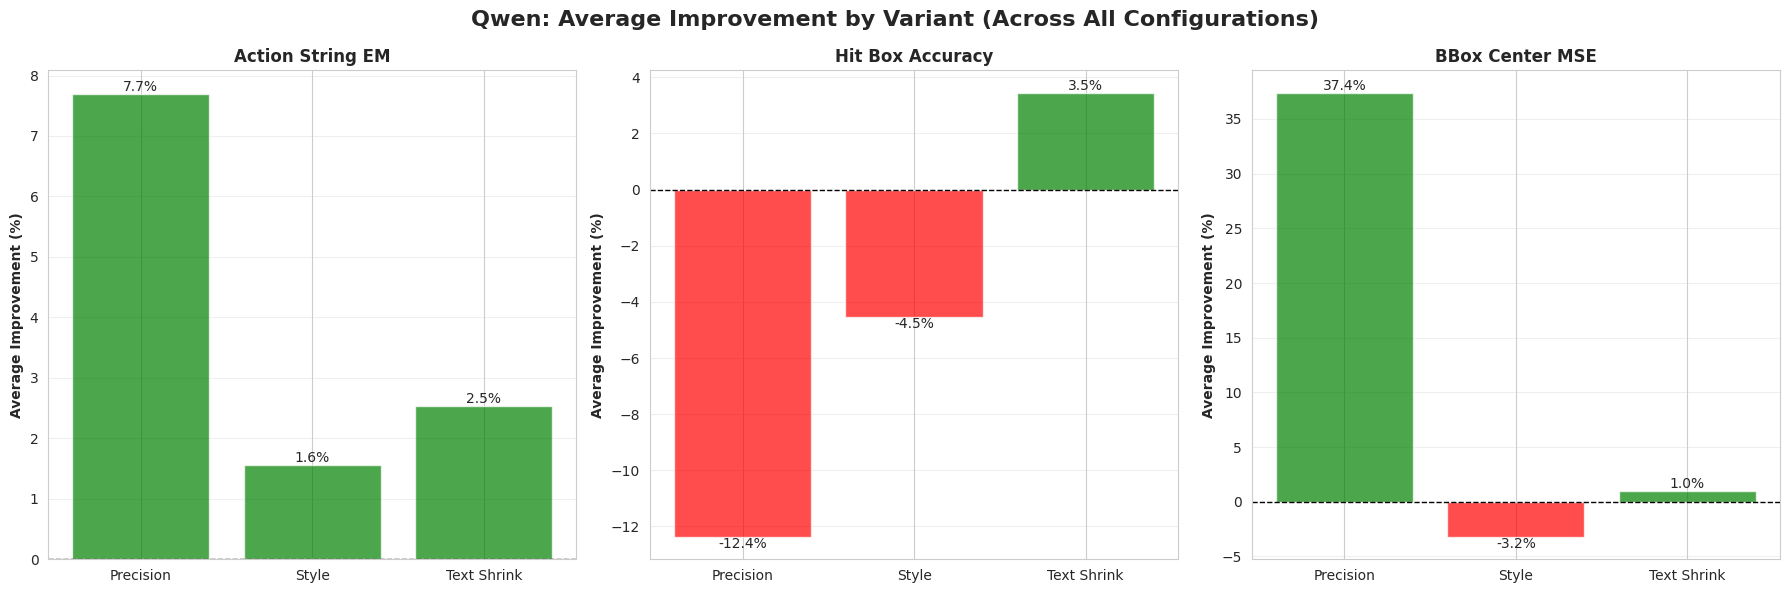

In [15]:
# Average improvement per variant across all configurations
variant_improvements = {}

for variant in ['precision', 'style', 'text_shrink']:
    variant_improvements[variant] = {
        'action_str_em': [],
        'hit_box_accuracy': [],
        'bbox_center_mse': []
    }
    
    for query_type in query_types:
        for has_thought in [False, True]:
            original = df[(df['query_type'] == query_type) & 
                         (df['variant'] == 'original') &
                         (df['has_thought'] == has_thought)]
            modified = df[(df['query_type'] == query_type) & 
                         (df['variant'] == variant) &
                         (df['has_thought'] == has_thought)]
            
            if len(original) > 0 and len(modified) > 0:
                for metric in ['action_str_em', 'hit_box_accuracy', 'bbox_center_mse']:
                    orig_val = original[metric].iloc[0]
                    mod_val = modified[metric].iloc[0]
                    
                    if orig_val > 0:
                        if metric == 'bbox_center_mse':
                            improvement = ((orig_val - mod_val) / orig_val) * 100
                        else:
                            improvement = ((mod_val - orig_val) / orig_val) * 100
                        variant_improvements[variant][metric].append(improvement)

# Plot average improvements
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Qwen: Average Improvement by Variant (Across All Configurations)', fontsize=16, fontweight='bold')

metrics_avg = [
    ('action_str_em', 'Action String EM', axes[0]),
    ('hit_box_accuracy', 'Hit Box Accuracy', axes[1]),
    ('bbox_center_mse', 'BBox Center MSE', axes[2]),
]

for metric_name, metric_label, ax in metrics_avg:
    variant_names = ['Precision', 'Style', 'Text Shrink']
    avg_improvements = [np.mean(variant_improvements[v][metric_name]) 
                       for v in ['precision', 'style', 'text_shrink']]
    
    colors_bar = ['green' if x > 0 else 'red' for x in avg_improvements]
    bars = ax.bar(variant_names, avg_improvements, color=colors_bar, alpha=0.7)
    
    ax.set_ylabel('Average Improvement (%)', fontweight='bold')
    ax.set_title(metric_label, fontweight='bold')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.grid(axis='y', alpha=0.3)
    
    for bar, val in zip(bars, avg_improvements):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1f}%', ha='center', va='bottom' if val > 0 else 'top', fontsize=10)

plt.tight_layout()
plt.show()